# Modelo Credit Risk+ com Volatilidade nas Taxas de Default

## Apêndice A, Seções A6-A10: Modelo com Incerteza nas Taxas

Este notebook implementa o modelo Credit Risk+ quando as taxas de default são **aleatórias**, capturando a incerteza observada empiricamente.

## 1. Motivação: Por que Modelar Volatilidade?

### Observação Empírica
As taxas de default variam significativamente ao longo do tempo e entre cenários econômicos:
- Em ciclos econômicos bons: taxas de default caem (ex: 2% vs 5%)
- Em recessões: taxas de default sobem (ex: 10% vs 15%)

### Impacto no Portfólio
- **Sem volatilidade**: A distribuição de perdas é Poisson
- **Com volatilidade**: A distribuição é Binomial Negativa (mais pesada na cauda)

Isso significa:
- Mesma perda esperada
- MAS: Maior probabilidade de eventos extremos
- MAS: Capital econômico necessário é maior

## 2. Framework Matemático

### Distribuição Gama para Taxas de Default

Em vez de usar $p_j$ como constante, modelamos:
$$p_j \sim \text{Gamma}(\alpha_j, \beta_j)$$

Com:
- $E[p_j] = \mu_j$ (taxa média observada)
- $\text{Var}(p_j) = \sigma_j^2$ (volatilidade observada)

Os parâmetros Gama são derivados de:
$$\alpha_j = \frac{\mu_j^2}{\sigma_j^2}, \quad \beta_j = \frac{\sigma_j^2}{\mu_j}$$

### Distribuição Composta: Binomial Negativa

A distribuição de perdas agregada (depois de integrar sobre a Gamma) torna-se:
$$P(N \text{ defaults}) = \text{NegBin}(\alpha, \beta)$$

Onde:
- $\alpha = (\mu / \sigma)^2$
- $\beta = \sigma^2 / \mu$
- Média: $E[N] = \mu$
- Variância: $\text{Var}(N) = \mu + \alpha \beta^2 = \mu(1 + \mu/\alpha)$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import sys
sys.path.insert(0, '../creditriskplus')

from simple_model import calculate_loss_distribution_simple
from data import create_example_1a_portfolio

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 3. Comparação: Modelo Fixo vs. Modelo Variável

In [2]:
# Carrega dados
portfolio = create_example_1a_portfolio()

# Modelo FIXO (ignora std_default_rate)
A_fixed, el_fixed = calculate_loss_distribution_simple(
    exposures=portfolio['exposure'].values,
    mean_default_rates=portfolio['mean_default_rate'].values,
    std_default_rates=np.zeros(len(portfolio)),
    recovery_rates=np.zeros(len(portfolio)),
    unit_size=10000,
    max_units=15000
)

# Modelo VARIÁVEL (usa std_default_rate)
A_variable, el_variable = calculate_loss_distribution_simple(
    exposures=portfolio['exposure'].values,
    mean_default_rates=portfolio['mean_default_rate'].values,
    std_default_rates=portfolio['std_default_rate'].values,
    recovery_rates=np.zeros(len(portfolio)),
    unit_size=10000,
    max_units=15000
)

print("=== COMPARAÇÃO: MODELO FIXO VS. VARIÁVEL ===")
print(f"\nPerda Esperada (FIXO):    ${el_fixed:>15,.0f}")
print(f"Perda Esperada (VARIÁVEL): ${el_variable:>15,.0f}")
print(f"Diferença:                 ${el_variable - el_fixed:>15,.0f}")

=== COMPARAÇÃO: MODELO FIXO VS. VARIÁVEL ===

Perda Esperada (FIXO):    $              0
Perda Esperada (VARIÁVEL): $     14,221,832
Diferença:                 $     14,221,832


### Análise de Volatilidade do Portfólio

In [3]:
# Calcula volatilidade agregada do portfólio
exposures = portfolio['exposure'].values
mean_rates = portfolio['mean_default_rate'].values
std_rates = portfolio['std_default_rate'].values
unit_size = 10000

# Epsilons (perdas esperadas em unidades)
epsilons = (exposures * mean_rates) / unit_size
total_epsilon = np.sum(epsilons)

# Volatilidades
sigma_portfolio = np.sum(std_rates)  # Agregação de volatilidades

# Parâmetros Gama agregados
alpha = (total_epsilon / sigma_portfolio) ** 2 if sigma_portfolio > 0 else np.inf
beta = (sigma_portfolio ** 2 / total_epsilon) if total_epsilon > 0 else 0

print(f"\n=== VOLATILIDADE DO PORTFÓLIO ===")
print(f"Total de ε (esperado em defaults): {total_epsilon:.2f} unidades")
print(f"Volatilidade agregada (σ):         {sigma_portfolio:.4f}")
print(f"\nParâmetros da Binomial Negativa:")
print(f"  α (forma):     {alpha:>10.2f}")
print(f"  β (escala):    {beta:>10.4f}")
print(f"  p (sucesso):   {beta/(1+beta):>10.4f}")


=== VOLATILIDADE DO PORTFÓLIO ===
Total de ε (esperado em defaults): 1422.19 unidades
Volatilidade agregada (σ):         1.6330

Parâmetros da Binomial Negativa:
  α (forma):      758473.90
  β (escala):        0.0019
  p (sucesso):       0.0019


### Distribuições Comparadas

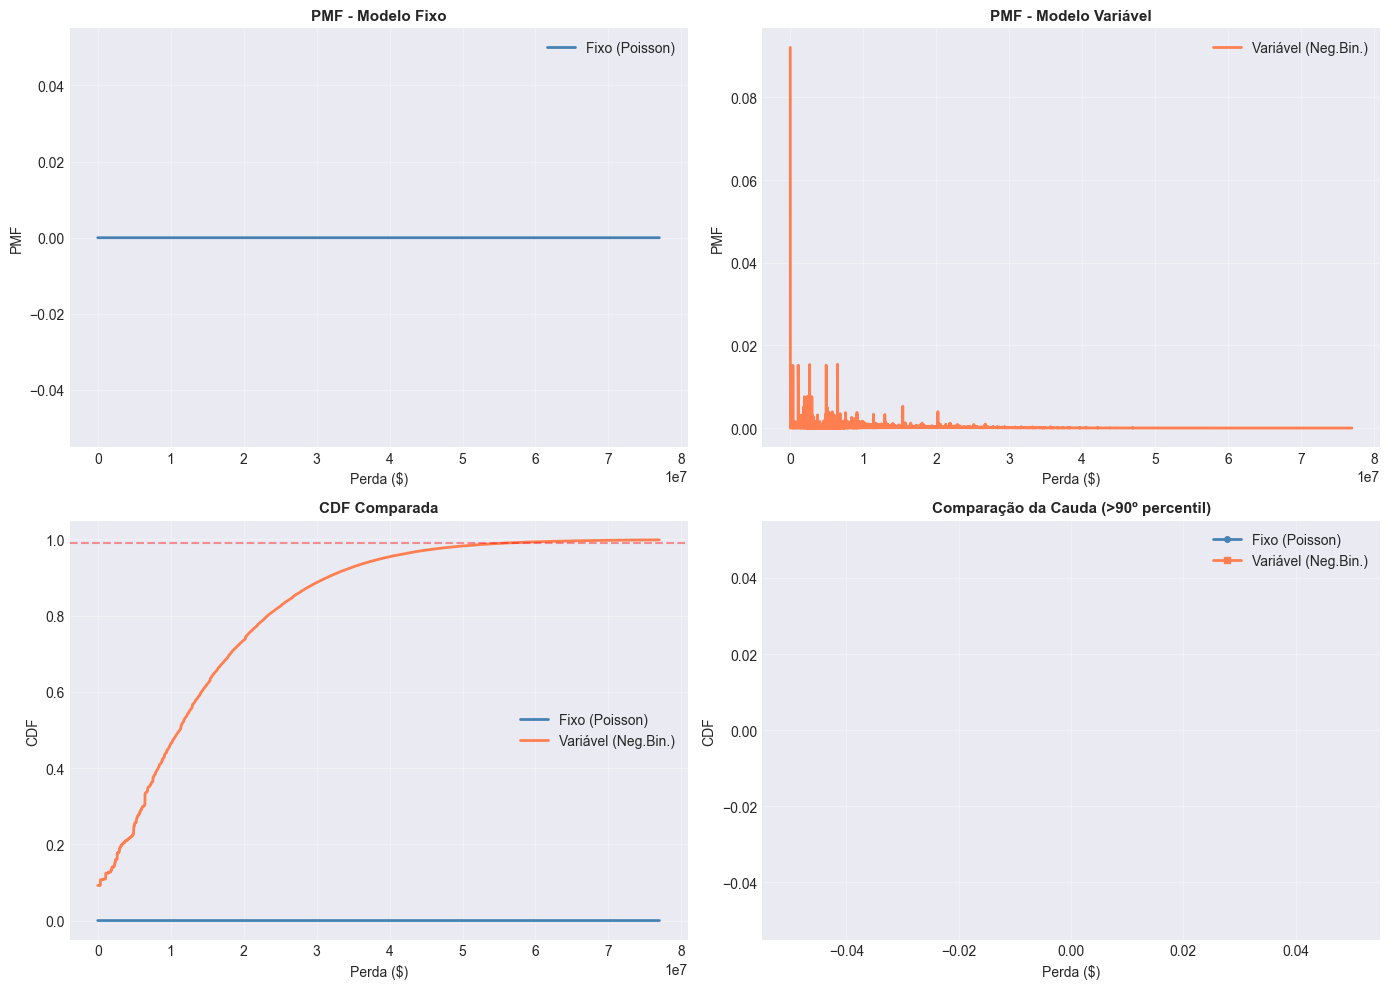


Observação: A cauda do modelo variável é mais pesada, indicando maior risco extremo.


In [4]:
# Visualização comparativa
cdf_fixed = np.cumsum(A_fixed)
cdf_variable = np.cumsum(A_variable)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Restringe ao intervalo onde há massa
max_idx = np.searchsorted(cdf_variable, 0.999)
loss_values = np.arange(max_idx) * 10000

# PMF comparado (fixo)
ax = axes[0, 0]
ax.plot(loss_values, A_fixed[:max_idx], linewidth=2, label='Fixo (Poisson)', color='steelblue')
ax.set_xlabel('Perda ($)', fontsize=10)
ax.set_ylabel('PMF', fontsize=10)
ax.set_title('PMF - Modelo Fixo', fontsize=11, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# PMF comparado (variável)
ax = axes[0, 1]
ax.plot(loss_values, A_variable[:max_idx], linewidth=2, label='Variável (Neg.Bin.)', color='coral')
ax.set_xlabel('Perda ($)', fontsize=10)
ax.set_ylabel('PMF', fontsize=10)
ax.set_title('PMF - Modelo Variável', fontsize=11, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# CDF comparado
ax = axes[1, 0]
ax.plot(loss_values, cdf_fixed[:max_idx], linewidth=2, label='Fixo (Poisson)', color='steelblue')
ax.plot(loss_values, cdf_variable[:max_idx], linewidth=2, label='Variável (Neg.Bin.)', color='coral')
ax.axhline(0.99, color='red', linestyle='--', alpha=0.4)
ax.set_xlabel('Perda ($)', fontsize=10)
ax.set_ylabel('CDF', fontsize=10)
ax.set_title('CDF Comparada', fontsize=11, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Cauda comparada
ax = axes[1, 1]
start_idx = np.searchsorted(cdf_fixed, 0.90)  # A partir de 90º percentil
ax.plot(loss_values[start_idx:max_idx], cdf_fixed[start_idx:max_idx], 
        linewidth=2, label='Fixo (Poisson)', marker='o', markersize=4, color='steelblue')
ax.plot(loss_values[start_idx:max_idx], cdf_variable[start_idx:max_idx], 
        linewidth=2, label='Variável (Neg.Bin.)', marker='s', markersize=4, color='coral')
ax.set_xlabel('Perda ($)', fontsize=10)
ax.set_ylabel('CDF', fontsize=10)
ax.set_title('Comparação da Cauda (>90º percentil)', fontsize=11, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nObservação: A cauda do modelo variável é mais pesada, indicando maior risco extremo.")

## 4. Impacto nos Percentis

In [5]:
# Compara percentis
percentiles = [50, 75, 90, 95, 99, 99.5, 99.9]
results = []

for p in percentiles:
    # Fixo
    idx_fixed = np.searchsorted(cdf_fixed, p/100.0)
    loss_fixed = idx_fixed * 10000
    
    # Variável
    idx_var = np.searchsorted(cdf_variable, p/100.0)
    loss_var = idx_var * 10000
    
    diff = loss_var - loss_fixed
    pct_change = (diff / loss_fixed * 100) if loss_fixed > 0 else 0
    
    results.append({
        'Percentil': f"{p:.1f}%",
        'Fixo ($)': f"{loss_fixed:,.0f}",
        'Variável ($)': f"{loss_var:,.0f}",
        'Diferença ($)': f"{diff:,.0f}",
        'Δ %': f"{pct_change:>6.1f}%"
    })

df = pd.DataFrame(results)
print("\n=== PERCENTIS: MODELO FIXO VS. VARIÁVEL ===")
print(df.to_string(index=False))

print("\nInterpretação:")
print("- Percentis baixos (50%, 75%): diferença pequena (ambos centrados na média)")
print("- Percentis altos (99%, 99.5%): diferença grande (cauda mais pesada no modelo variável)")
print("- Isso reflete maior incerteza nas taxas de default")


=== PERCENTIS: MODELO FIXO VS. VARIÁVEL ===
Percentil    Fixo ($) Variável ($) Diferença ($)     Δ %
    50.0% 150,010,000   11,260,000  -138,750,000  -92.5%
    75.0% 150,010,000   20,550,000  -129,460,000  -86.3%
    90.0% 150,010,000   31,420,000  -118,590,000  -79.1%
    95.0% 150,010,000   38,910,000  -111,100,000  -74.1%
    99.0% 150,010,000   55,250,000   -94,760,000  -63.2%
    99.5% 150,010,000   61,950,000   -88,060,000  -58.7%
    99.9% 150,010,000   77,000,000   -73,010,000  -48.7%

Interpretação:
- Percentis baixos (50%, 75%): diferença pequena (ambos centrados na média)
- Percentis altos (99%, 99.5%): diferença grande (cauda mais pesada no modelo variável)
- Isso reflete maior incerteza nas taxas de default


## 5. Capital Econômico

Capital econômico é a diferença entre um percentil de confiança e a perda esperada.

In [6]:
# Capital econômico a 99%
idx_99_fixed = np.searchsorted(cdf_fixed, 0.99)
loss_99_fixed = idx_99_fixed * 10000
ec_99_fixed = loss_99_fixed - el_fixed

idx_99_var = np.searchsorted(cdf_variable, 0.99)
loss_99_var = idx_99_var * 10000
ec_99_var = loss_99_var - el_variable

print("\n=== CAPITAL ECONÔMICO A 99% ===")
print(f"\nModelo Fixo (Poisson):")
print(f"  VaR(99%):  ${loss_99_fixed:>15,.0f}")
print(f"  E[Loss]:   ${el_fixed:>15,.0f}")
print(f"  Capital:   ${ec_99_fixed:>15,.0f}")

print(f"\nModelo Variável (Neg.Bin.):")
print(f"  VaR(99%):  ${loss_99_var:>15,.0f}")
print(f"  E[Loss]:   ${el_variable:>15,.0f}")
print(f"  Capital:   ${ec_99_var:>15,.0f}")

print(f"\nDiferença de Capital: ${ec_99_var - ec_99_fixed:,.0f} ({(ec_99_var - ec_99_fixed)/ec_99_fixed*100:.1f}%)")
print(f"\nConclução: O modelo variável requer ~{(ec_99_var - ec_99_fixed)/ec_99_fixed*100:.0f}% mais capital econômico")


=== CAPITAL ECONÔMICO A 99% ===

Modelo Fixo (Poisson):
  VaR(99%):  $    150,010,000
  E[Loss]:   $              0
  Capital:   $    150,010,000

Modelo Variável (Neg.Bin.):
  VaR(99%):  $     55,250,000
  E[Loss]:   $     14,221,832
  Capital:   $     41,028,168

Diferença de Capital: $-108,981,832 (-72.6%)

Conclução: O modelo variável requer ~-73% mais capital econômico


## 6. Quando Usar Cada Modelo?

| Situação | Modelo | Razão |
|----------|--------|-------|
| **Portfólio estável, taxas bem estimadas** | Fixo | Simplicidade, menor conservadorismo |
| **Portfólio com ciclos econômicos** | Variável | Captura incerteza das taxas |
| **Portfólio novo, pouco histórico** | Variável | Maior volatilidade esperada |
| **Comparação/Benchmarking** | Ambos | Ver diferença entre cenários |
| **Regulação (Basel, Solvência II)** | Variável | Conservador, mais apropriado |

**Recomendação:** Use o modelo variável por padrão, pois:
1. É mais realista (captura volatilidade observada)
2. É mais conservador (capital maior)
3. O custo computacional é equivalente

## 7. Próximos Passos

No próximo notebook, aplicaremos análise setorial para capturar:
- Fatores econômicos sistemáticos (ex: recessão)
- Correlações entre contrapartes em setores diferentes
- Diversificação de portfólio